## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization, text feature extraction, machine learning, and model evaluation.

In [1]:
import glob
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 2. Dataset Loading

The dataset is distributed across multiple CSV files. Each file contains Nepali news articles and associated metadata.

The expected columns are:

- `news_context`: Nepali news text
- `label`: Binary classification label
- `category`: News category
- `source_type`: Source of the news
- `news_id`: Unique news identifier
- `generated_at`: Timestamp
- `meta_intent`: Intended communication style
- `meta_style`: Writing style

The `news_context` column is the primary input feature, while `label` is the target variable.

In [2]:
import glob
import os
import pandas as pd

data_path = "/kaggle/input/datasets/ashoknepal/nepali-fake-news-detection"

csv_files = sorted(
    glob.glob(os.path.join(data_path, "nepali_news_part_*.csv"))
)

print("Number of CSV files found:", len(csv_files))

for file in csv_files:
    print(os.path.basename(file))

Number of CSV files found: 8
nepali_news_part_0001.csv
nepali_news_part_0002.csv
nepali_news_part_0003.csv
nepali_news_part_0004.csv
nepali_news_part_0005.csv
nepali_news_part_0006.csv
nepali_news_part_0007.csv
nepali_news_part_0008.csv


## 3. Reading Individual Dataset Files

Each CSV file is loaded separately before combining them into a single DataFrame.

Some files contain malformed CSV rows with an incorrect number of fields. Therefore, the files are loaded using a parser configuration that skips malformed records rather than allowing them to corrupt the complete dataset.

The number of rows and columns for each file is recorded for validation.

In [3]:
dataframes = []

for file in csv_files:
    print("\n" + "=" * 70)
    print("FILE:", os.path.basename(file))
    print("=" * 70)

    try:
        df = pd.read_csv(
            file,
            on_bad_lines="warn"
        )

        dataframes.append(df)

        print("Shape:", df.shape)
        print("Columns:", df.columns.tolist())

    except Exception as e:
        print("ERROR:", e)


FILE: nepali_news_part_0001.csv
Shape: (8776, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']

FILE: nepali_news_part_0002.csv


/tmp/ipykernel_58/956969894.py:9: ParserWarning: Skipping line 1496: expected 8 fields, saw 9
Skipping line 1497: expected 8 fields, saw 9
Skipping line 1498: expected 8 fields, saw 9
Skipping line 1499: expected 8 fields, saw 9
Skipping line 1500: expected 8 fields, saw 9
Skipping line 4455: expected 8 fields, saw 9
Skipping line 4456: expected 8 fields, saw 9
Skipping line 4457: expected 8 fields, saw 9
Skipping line 4458: expected 8 fields, saw 9
Skipping line 4459: expected 8 fields, saw 9
Skipping line 4460: expected 8 fields, saw 9
Skipping line 4461: expected 8 fields, saw 9
Skipping line 4462: expected 8 fields, saw 9
Skipping line 4463: expected 8 fields, saw 9
Skipping line 4464: expected 8 fields, saw 9
Skipping line 4465: expected 8 fields, saw 9
Skipping line 4466: expected 8 fields, saw 9
Skipping line 4467: expected 8 fields, saw 9
Skipping line 4640: expected 8 fields, saw 9
Skipping line 4641: expected 8 fields, saw 9
Skipping line 4642: expected 8 fields, saw 9
Skippi

Shape: (8229, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']

FILE: nepali_news_part_0003.csv
Shape: (8052, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']

FILE: nepali_news_part_0004.csv


/tmp/ipykernel_58/956969894.py:9: ParserWarning: Skipping line 394: expected 8 fields, saw 9
Skipping line 395: expected 8 fields, saw 9
Skipping line 396: expected 8 fields, saw 9
Skipping line 397: expected 8 fields, saw 9
Skipping line 398: expected 8 fields, saw 9
Skipping line 399: expected 8 fields, saw 9
Skipping line 400: expected 8 fields, saw 9
Skipping line 401: expected 8 fields, saw 9
Skipping line 402: expected 8 fields, saw 9
Skipping line 403: expected 8 fields, saw 9
Skipping line 404: expected 8 fields, saw 9
Skipping line 405: expected 8 fields, saw 9
Skipping line 406: expected 8 fields, saw 9
Skipping line 407: expected 8 fields, saw 9
Skipping line 408: expected 8 fields, saw 9
Skipping line 409: expected 8 fields, saw 9
Skipping line 1136: expected 8 fields, saw 9
Skipping line 1137: expected 8 fields, saw 9
Skipping line 1138: expected 8 fields, saw 9
Skipping line 1139: expected 8 fields, saw 9
Skipping line 1140: expected 8 fields, saw 9
Skipping line 1141: ex

Shape: (7085, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']

FILE: nepali_news_part_0005.csv
Shape: (7275, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']

FILE: nepali_news_part_0006.csv
Shape: (7269, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']

FILE: nepali_news_part_0007.csv
Shape: (7406, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']

FILE: nepali_news_part_0008.csv
Shape: (1652, 8)
Columns: ['news_context', 'label', 'category', 'source_type', 'news_id', 'generated_at', 'meta_intent', 'meta_style']


## 4. Dataset Summary

After loading all valid CSV files, the individual DataFrames are combined into a single dataset.

This provides a unified dataset for subsequent data cleaning, exploratory analysis, feature extraction, and machine learning.

In [4]:
print("\nNumber of datasets loaded:", len(dataframes))

for i, df in enumerate(dataframes):
    print(
        f"Dataset {i + 1}: "
        f"{df.shape[0]} rows × {df.shape[1]} columns"
    )


Number of datasets loaded: 8
Dataset 1: 8776 rows × 8 columns
Dataset 2: 8229 rows × 8 columns
Dataset 3: 8052 rows × 8 columns
Dataset 4: 7085 rows × 8 columns
Dataset 5: 7275 rows × 8 columns
Dataset 6: 7269 rows × 8 columns
Dataset 7: 7406 rows × 8 columns
Dataset 8: 1652 rows × 8 columns


In [5]:
for i, df in enumerate(dataframes):

    print("\n" + "=" * 70)
    print(f"DATASET {i + 1}")
    print("=" * 70)

    print("Shape:", df.shape)

    print("\nLabel data type:")
    print(df["label"].dtype)

    print("\nLabel values:")
    print(df["label"].value_counts(dropna=False))


DATASET 1
Shape: (8776, 8)

Label data type:
float64

Label values:
label
0.0    4519
1.0    4252
NaN       5
Name: count, dtype: int64

DATASET 2
Shape: (8229, 8)

Label data type:
int64

Label values:
label
0    4227
1    4002
Name: count, dtype: int64

DATASET 3
Shape: (8052, 8)

Label data type:
float64

Label values:
label
0.0    4227
1.0    3820
NaN       5
Name: count, dtype: int64

DATASET 4
Shape: (7085, 8)

Label data type:
float64

Label values:
label
0.0    3664
1.0    3419
NaN       2
Name: count, dtype: int64

DATASET 5
Shape: (7275, 8)

Label data type:
int64

Label values:
label
0    3671
1    3604
Name: count, dtype: int64

DATASET 6
Shape: (7269, 8)

Label data type:
int64

Label values:
label
0    3658
1    3611
Name: count, dtype: int64

DATASET 7
Shape: (7406, 8)

Label data type:
int64

Label values:
label
0    3762
1    3644
Name: count, dtype: int64

DATASET 8
Shape: (1652, 8)

Label data type:
int64

Label values:
label
0    840
1    812
Name: count, dtype: in

In [6]:
# Combine all 8 datasets
combined_df = pd.concat(
    dataframes,
    ignore_index=True
)

print("Combined dataset shape:", combined_df.shape)

Combined dataset shape: (55744, 8)


## 5. Dataset Structure

The combined dataset contains 55,744 records and eight columns.

The dataset contains one target variable (`label`), one primary textual feature (`news_context`), and several metadata fields.

The structure and data types are inspected before performing data cleaning.

In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55744 entries, 0 to 55743
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   news_context  55744 non-null  object 
 1   label         55732 non-null  float64
 2   category      55671 non-null  object 
 3   source_type   55611 non-null  object 
 4   news_id       55742 non-null  object 
 5   generated_at  55351 non-null  object 
 6   meta_intent   54968 non-null  object 
 7   meta_style    54892 non-null  object 
dtypes: float64(1), object(7)
memory usage: 3.4+ MB


### Initial Observation

The `news_context` column contains the Nepali news text used for classification.

The `label` column represents the target class:

- `0` → Real news
- `1` → Fake news

The remaining columns contain metadata associated with each news article.

## 6. Sample Records

The first few records are examined to understand the structure and content of the news articles.

In [8]:
combined_df.head()

,news_context,label,category,source_type,news_id,generated_at,meta_intent,meta_style
0,राष्ट्रपति को घोषणा अनुसार राष्ट्रिय बजेट २०२५...,0.0,politics,online_portal,NP_0000001,2026-01-15T12:27:38.340711,informative,neutral
1,नेपाल बैंकले ब्याज दरमा ०.२५ प्रतिशत अंकको वृद...,0.0,economy,online_portal,NP_0000002,2026-01-15T12:27:38.340902,informative,neutral
2,स्वास्थ्य विभागले कोविड‑१९ सन्दर्भमा नवीनतम डे...,0.0,health,online_portal,NP_0000003,2026-01-15T12:27:38.340915,informative,neutral
3,नगरपालिकाले क्यालेन्डर २०२६ को सामाजिक कार्यक्...,0.0,society,online_portal,NP_0000004,2026-01-15T12:27:38.340923,informative,neutral
4,नेपालमा पहिलो पूर्ण रूपमा क्यूआर कोड आधारित शै...,0.0,technology,online_portal,NP_0000005,2026-01-15T12:27:38.340931,informative,neutral


## 7. Missing Value Analysis

Missing values are examined across all columns.

Missing values in the textual feature or target variable require particular attention because they can prevent a record from being used for supervised learning.

Metadata fields such as `generated_at`, `meta_intent`, and `meta_style` are not required for the primary text classification task.

In [9]:
missing_values = combined_df.isnull().sum()

missing_percentage = (
    combined_df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
news_context,0,0.00
label,12,0.02
category,73,0.13
source_type,133,0.24
news_id,2,0.00
generated_at,393,0.71
meta_intent,776,1.39
meta_style,852,1.53


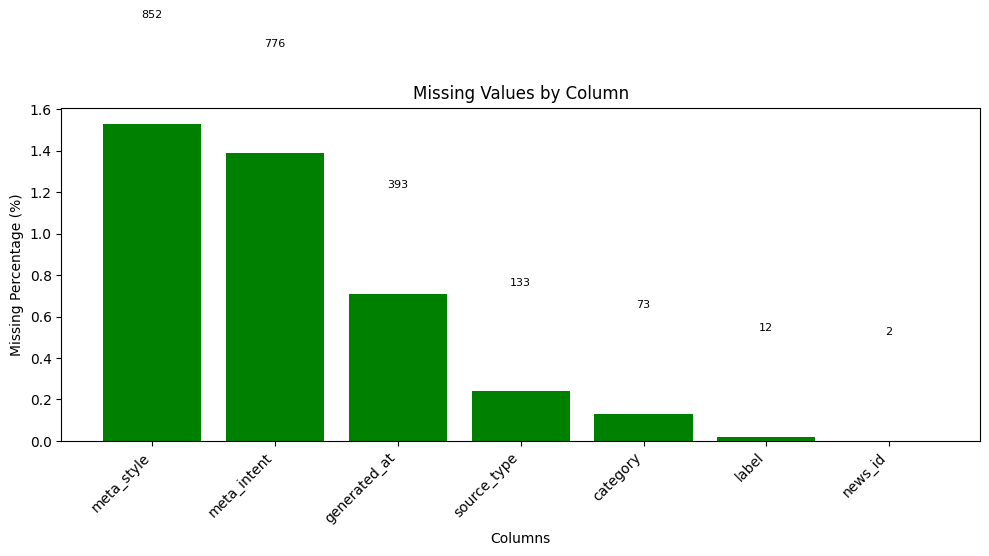

In [11]:
import matplotlib.pyplot as plt

# Keep only columns that actually have missing values
missing_summary_plot = missing_summary[missing_summary["Missing Count"] > 0].sort_values(
    "Missing Percentage", ascending=False
)

fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(missing_summary_plot.index, missing_summary_plot["Missing Percentage"], color="green")
ax1.set_ylabel("Missing Percentage (%)")
ax1.set_xlabel("Columns")
ax1.set_title("Missing Values by Column")
plt.xticks(rotation=45, ha="right")

# Annotate bars with the raw count
for bar, count in zip(bars, missing_summary_plot["Missing Count"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{int(count)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Target Label Validation

Because the task is binary fake-news classification, the target variable must contain only two valid classes: `0` and `1`.

The label distribution is inspected to identify missing or invalid labels before model training.

In [12]:
print("Label distribution:")
print(combined_df["label"].value_counts(dropna=False))

Label distribution:
label
0.0    28568
1.0    27164
NaN       12
Name: count, dtype: int64


## 9. Handling Missing Target Labels

Records without a valid target label cannot be used for supervised classification.

Therefore, rows with missing labels are removed from the modeling dataset.

In [13]:
# Remove rows where the target label is missing

print("Rows before removing missing labels:", len(combined_df))

combined_df = combined_df.dropna(
    subset=["label"]
).copy()

print("Rows after removing missing labels:", len(combined_df))

Rows before removing missing labels: 55744
Rows after removing missing labels: 55732


In [14]:
combined_df["label"] = combined_df["label"].astype(int)

In [15]:
print(combined_df["label"].dtype)

int64


In [16]:
print(combined_df["label"].value_counts())

label
0    28568
1    27164
Name: count, dtype: int64


In [17]:
label_percentage = (
    combined_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(label_percentage)

label
0    51.26
1    48.74
Name: proportion, dtype: float64


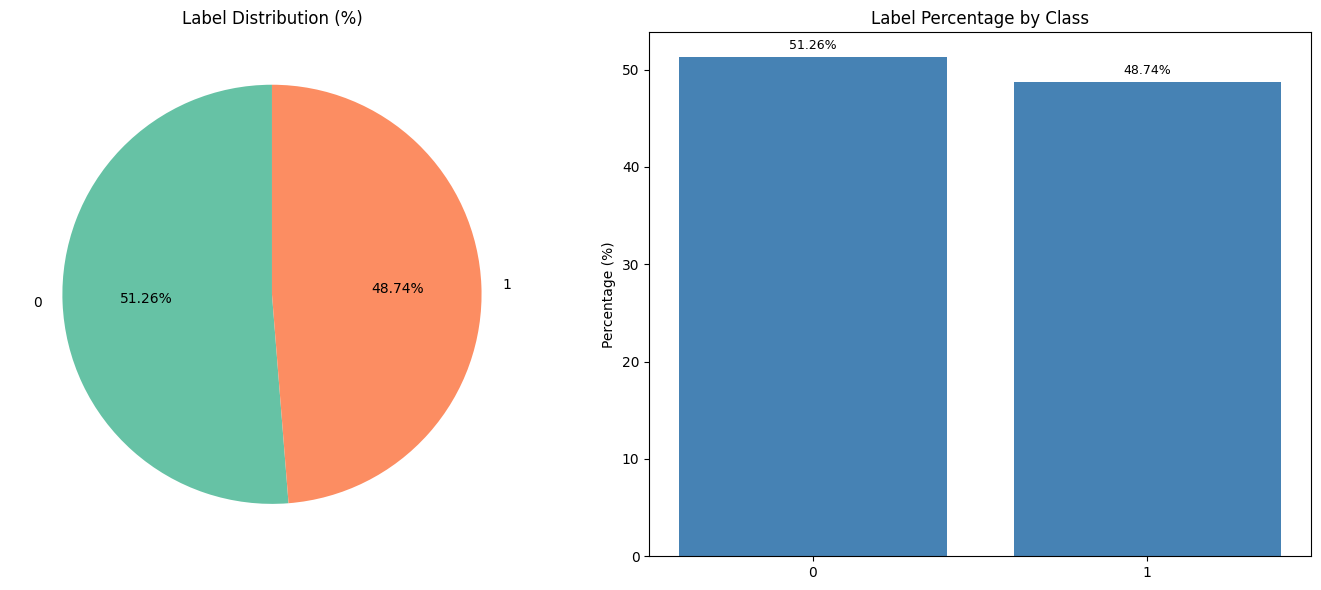

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(
    label_percentage,
    labels=label_percentage.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=plt.cm.Set2.colors
)
axes[0].set_title("Label Distribution (%)")

# Bar chart
bars = axes[1].bar(label_percentage.index.astype(str), label_percentage.values, color="steelblue")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Label Percentage by Class")
for bar, pct in zip(bars, label_percentage.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{pct}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 10. Duplicate Analysis

Duplicate records can cause data leakage and may artificially increase model performance.

Therefore, duplicate news text, complete rows, and news identifiers are examined separately.

In [19]:
print(
    "Duplicate news_context:",
    combined_df["news_context"].duplicated().sum()
)

Duplicate news_context: 78


In [20]:
duplicate_news = combined_df[
    combined_df["news_context"].duplicated(keep=False)
].sort_values("news_context")

print("Rows involved in duplicate news:", len(duplicate_news))

#duplicate_news.head(20)

Rows involved in duplicate news: 150


In [21]:
duplicate_label_check = (
    duplicate_news
    .groupby("news_context")["label"]
    .nunique()
)

print(
    "Duplicate texts having different labels:",
    (duplicate_label_check > 1).sum()
)

Duplicate texts having different labels: 0


In [22]:
print(
    "Duplicate news_context:",
    combined_df["news_context"].duplicated().sum()
)

Duplicate news_context: 78


In [23]:
print(
    "Duplicate complete rows:",
    combined_df.duplicated().sum()
)

print(
    "Duplicate news_id:",
    combined_df["news_id"].duplicated().sum()
)

Duplicate complete rows: 0
Duplicate news_id: 19


## 11. Removing Duplicate News Text

Since the same news text may occur multiple times across dataset files, duplicate `news_context` records are removed.

The first occurrence is retained.

In [24]:
print(
    "Rows before removing duplicate texts:",
    len(combined_df)
)

combined_df = combined_df.drop_duplicates(
    subset=["news_context"],
    keep="first"
).copy()

print(
    "Rows after removing duplicate texts:",
    len(combined_df)
)

Rows before removing duplicate texts: 55732
Rows after removing duplicate texts: 55654


## 12. Class Distribution

The distribution of real and fake news is calculated after data cleaning.

A relatively balanced dataset reduces the risk of a classifier becoming biased toward one class.

In [25]:
print("Label distribution:")
print(combined_df["label"].value_counts())

Label distribution:
label
0    28512
1    27142
Name: count, dtype: int64


In [26]:
print("\nLabel percentage:")

print(
    combined_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Label percentage:
label
0    51.23
1    48.77
Name: proportion, dtype: float64


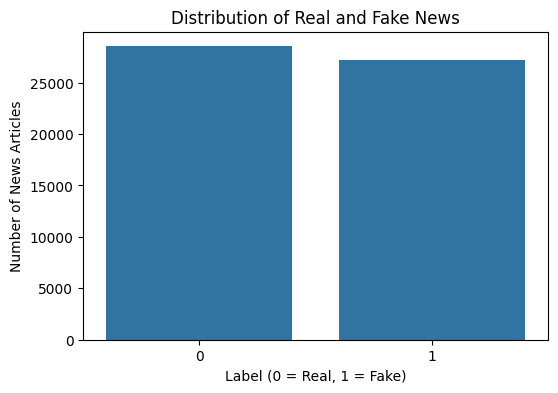

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=combined_df,
    x="label"
)

plt.title("Distribution of Real and Fake News")
plt.xlabel("Label (0 = Real, 1 = Fake)")
plt.ylabel("Number of News Articles")

plt.show()

## 13. Text Quality Analysis

The quality of the textual input is examined before feature extraction.

The following checks are performed:

- Empty news articles
- Extremely short texts
- Minimum text length
- Maximum text length
- Average text length
- Median text length

These checks help identify unusable or suspicious text records.

In [28]:
empty_text = combined_df[
    combined_df["news_context"].str.strip().eq("")
]

print("Empty news_context rows:", len(empty_text))

Empty news_context rows: 0


In [29]:
short_text = combined_df[
    combined_df["news_context"].str.strip().str.len() < 10
]

print("Texts shorter than 10 characters:", len(short_text))

Texts shorter than 10 characters: 0


In [30]:
text_lengths = combined_df["news_context"].str.len()

print("Minimum text length:", text_lengths.min())
print("Maximum text length:", text_lengths.max())
print("Average text length:", round(text_lengths.mean(), 2))
print("Median text length:", text_lengths.median())

Minimum text length: 24
Maximum text length: 2505
Average text length: 134.29
Median text length: 125.0


In [31]:
model_df = combined_df[
    ["news_context", "label"]
].copy()

print("Model dataset shape:", model_df.shape)

Model dataset shape: (55654, 2)


In [32]:
model_df.head()

,news_context,label
0,राष्ट्रपति को घोषणा अनुसार राष्ट्रिय बजेट २०२५...,0
1,नेपाल बैंकले ब्याज दरमा ०.२५ प्रतिशत अंकको वृद...,0
2,स्वास्थ्य विभागले कोविड‑१९ सन्दर्भमा नवीनतम डे...,0
3,नगरपालिकाले क्यालेन्डर २०२६ को सामाजिक कार्यक्...,0
4,नेपालमा पहिलो पूर्ण रूपमा क्यूआर कोड आधारित शै...,0


In [33]:
print(model_df["news_context"].dtype)
print(model_df["label"].dtype)

object
int64


In [34]:
model_df["news_context"] = model_df["news_context"].astype(str)
model_df["label"] = model_df["label"].astype(int)

In [35]:
for i in range(5):
    print("=" * 80)
    print("Label:", model_df.iloc[i]["label"])
    print(model_df.iloc[i]["news_context"])

Label: 0
राष्ट्रपति को घोषणा अनुसार राष्ट्रिय बजेट २०२५-२६: नेपाल सरकारले २०२५-२६ आर्थिक वर्षको बजेट १.८ ट्रिलियन नेपाली रुपैयाँको प्रस्ताव पेश गर्यो। बजेटमा स्वास्थ्य, शिक्षा र ग्रामीण विकासमा २० प्रतिशत वृद्धि गरिएको छ। प्रमुख विषयहरूमा डिजिटल इन्फ्रास्ट्रक्चर र जलवायु परिवर्तनको अनुकूलनमा ५ प्रतिशतको अनुदान दिइएको छ। सरकारले १० प्रतिशतको कर दरको परिवर्तन तथा सामाजिक सुरक्षा योजनामा नयाँ योगदान योजना प्रस्ताव गरेको छ। यो बजेटले देशको आर्थिक स्थिरता र समावेशी विकासको लक्ष्यलाई सुदृढ गर्ने अपेक्षा गरिएको छ।
Label: 0
नेपाल बैंकले ब्याज दरमा ०.२५ प्रतिशत अंकको वृद्धिलाई सार्वजनिक गर्यो: नेपाल बैंक (RBI) ले २०२५‑२६ आर्थिक वर्षको मध्यावधिमा कर्जा ब्याज दर ११.२५% मा वृद्धि गरेको छ। ब्याज दर वृद्धिले मुद्रास्फीति नियन्त्रणमा मद्दत गर्ने अपेक्षा गरिएको छ। बैंकले वित्तीय समावेशीकरणलाई प्रोत्साहन गर्ने नयाँ नीतिहरू पनि प्रस्ताव गरेको छ। यस निर्णयले घरेलु ऋण मागमा केही कमी ल्याउने सम्भावना छ। बैंकले यो निर्णय राष्ट्रिय वित्तीय स्थिरता र आर्थिक वृद्धिलाई सुनिश्चित गर्ने उद्देश्यले गरेको बताएको छ।

## 14. Qualitative Inspection of News Samples

A small number of examples from both classes are manually inspected to understand the linguistic characteristics of the dataset.

This step does not replace quantitative evaluation; it provides qualitative insight into the differences between real and fake news samples.

In [36]:
print("LABEL 0 EXAMPLE")
print(
    model_df[model_df["label"] == 0]
    ["news_context"]
    .iloc[0]
)

print("\n" + "=" * 80)

print("LABEL 1 EXAMPLE")
print(
    model_df[model_df["label"] == 1]
    ["news_context"]
    .iloc[0]
)

LABEL 0 EXAMPLE
राष्ट्रपति को घोषणा अनुसार राष्ट्रिय बजेट २०२५-२६: नेपाल सरकारले २०२५-२६ आर्थिक वर्षको बजेट १.८ ट्रिलियन नेपाली रुपैयाँको प्रस्ताव पेश गर्यो। बजेटमा स्वास्थ्य, शिक्षा र ग्रामीण विकासमा २० प्रतिशत वृद्धि गरिएको छ। प्रमुख विषयहरूमा डिजिटल इन्फ्रास्ट्रक्चर र जलवायु परिवर्तनको अनुकूलनमा ५ प्रतिशतको अनुदान दिइएको छ। सरकारले १० प्रतिशतको कर दरको परिवर्तन तथा सामाजिक सुरक्षा योजनामा नयाँ योगदान योजना प्रस्ताव गरेको छ। यो बजेटले देशको आर्थिक स्थिरता र समावेशी विकासको लक्ष्यलाई सुदृढ गर्ने अपेक्षा गरिएको छ।

LABEL 1 EXAMPLE
राजनीतिक दलको प्रमुखले विश्वकप जीत्नका लागि जादुई मन्त्र सार्वजनिक गर्‍यो: जनकपुरको प्रमुख नेता श्री अमिताभ भट्टाले विश्वकप विजेता हुने आशयमा एक जादुई मन्त्र सार्वजनिक गर्‍यो। मन्त्रमा काली बत्ती, नीलो धुंगो, र गन्धयुक्त फूलको प्रयोग गर्ने वादा गरिएको छ। बिश्वको सबै देशले यो मन्त्रको शक्ति विश्वास गरेपछि खेलाडीहरूले आफ्नो प्रदर्शनमा अलौकिक सुधार अनुभव गरेको दाबी गरेका छन्। यो मन्त्रको प्रभावकारीता वैज्ञानिक प्रमाणले पुष्टि भएको बताइन्छ। सरकारले यो मन्त्रलाई र

## 15. Preparing the Modeling Dataset

Only the two variables required for the text classification task are retained:

- `news_context` — input text
- `label` — target class

Metadata fields are excluded from the baseline text classification model.

In [37]:
# Create the modeling dataset

model_df = combined_df[
    ["news_context", "label"]
].copy()

# Remove rows with missing labels
model_df = model_df.dropna(subset=["label"])

# Convert labels to integer
model_df["label"] = model_df["label"].astype(int)

# Remove any accidental invalid labels
model_df = model_df[
    model_df["label"].isin([0, 1])
].copy()

# Reset index
model_df = model_df.reset_index(drop=True)

print("Modeling dataset shape:", model_df.shape)
print("\nLabel distribution:")
print(model_df["label"].value_counts())

print("\nLabel percentage:")
print(
    model_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Modeling dataset shape: (55654, 2)

Label distribution:
label
0    28512
1    27142
Name: count, dtype: int64

Label percentage:
label
0    51.23
1    48.77
Name: proportion, dtype: float64


In [38]:
print("Missing values:")
print(model_df.isnull().sum())

print("\nDuplicate texts:")
print(model_df["news_context"].duplicated().sum())

print("\nInvalid labels:")
print(
    (~model_df["label"].isin([0, 1])).sum()
)

Missing values:
news_context    0
label           0
dtype: int64

Duplicate texts:
0

Invalid labels:
0


## 16. Train-Test Split

The cleaned dataset is divided into training and testing subsets.

The training set is used to learn the relationship between Nepali news text and the target label.

The test set is kept separate and is used only for evaluating the final model performance.

Stratification is applied to preserve the class distribution in both subsets.

In [39]:
from sklearn.model_selection import train_test_split

X = model_df["news_context"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 44523
Testing samples: 11131

Training label distribution:
label
0    22809
1    21714
Name: count, dtype: int64

Testing label distribution:
label
0    5703
1    5428
Name: count, dtype: int64


## 17. TF-IDF Feature Extraction

Machine learning algorithms cannot directly process raw Nepali text.

Therefore, the news articles are transformed into numerical feature vectors using Term Frequency-Inverse Document Frequency (TF-IDF).

TF-IDF assigns higher importance to terms that are frequent within a document but relatively uncommon across the complete collection of documents.

The resulting sparse matrix is used as input to the machine learning classifiers.

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (44523, 32067)
Testing TF-IDF shape: (11131, 32067)


## 18. Classification Architecture

The TF-IDF representation is supplied to multiple machine learning classifiers.

The baseline classification models evaluated in this study are:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest
6. K-Nearest Neighbors (KNN)

Each classifier produces predictions on the unseen test set. The predictions are then evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

### Figure 6. Classification Architecture

```text
                  ┌─────────────────┐
                  │   Nepali News   │
                  │      Text       │
                  └────────┬────────┘
                           │
                           ▼
                  ┌─────────────────┐
                  │    TF-IDF       │
                  │ Feature Matrix  │
                  └────────┬────────┘
                           │
          ┌────────────────┼─────────────────┐
          │                │                 │
          ▼                ▼                 ▼
   ┌────────────┐   ┌─────────────┐   ┌────────────┐
   │ Naive Bayes│   │  Logistic   │   │    SVM     │
   │            │   │ Regression  │   │            │
   └──────┬─────┘   └──────┬──────┘   └─────┬──────┘
          │                │                 │
          └────────────────┼─────────────────┘
                           │
          ┌────────────────┼─────────────────┐
          │                │                 │
          ▼                ▼                 ▼
   ┌────────────┐   ┌────────────┐   ┌────────────┐
   │ Decision   │   │  Random    │   │    KNN     │
   │ Tree       │   │  Forest    │   │            │
   └──────┬─────┘   └─────┬──────┘   └─────┬──────┘
          │                │                 │
          └────────────────┼─────────────────┘
                           ▼
                   ┌──────────────┐
                   │ Predictions  │
                   └──────┬───────┘
                          ▼
                   ┌──────────────┐
                   │  Evaluation  │
                   └──────────────┘




# 19. Model Training

Six supervised machine learning classifiers are trained using the TF-IDF representation.

The objective is to compare different classification algorithms under the same feature representation and train-test split.

In [41]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),
    "SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

trained_models = {}

results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    trained_models[name] = model

    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.971162,0.980976,0.959469,0.970103
1,Logistic Regression,0.965232,0.976375,0.951732,0.963896
0,Naive Bayes,0.961639,0.975471,0.945099,0.960045
4,Random Forest,0.959213,0.972096,0.943441,0.957554
5,KNN,0.944749,0.969195,0.915807,0.941745
3,Decision Tree,0.914293,0.914106,0.909727,0.911911


## 21. Classification Report

The classification report provides precision, recall, F1-score, and support separately for the real-news and fake-news classes.

This provides a more detailed evaluation than accuracy alone.

In [50]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Real", "Fake"]
    )
)

              precision    recall  f1-score   support

        Real       0.92      0.97      0.95      5703
        Fake       0.97      0.92      0.94      5428

    accuracy                           0.94     11131
   macro avg       0.95      0.94      0.94     11131
weighted avg       0.95      0.94      0.94     11131



## 22. Confusion Matrix

A confusion matrix is used to examine the types of classification errors made by the model.

For binary classification, the matrix contains:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

This provides a clearer understanding of whether the model is more likely to incorrectly classify real news as fake or fake news as real.

In [52]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5545  158]
 [ 457 4971]]


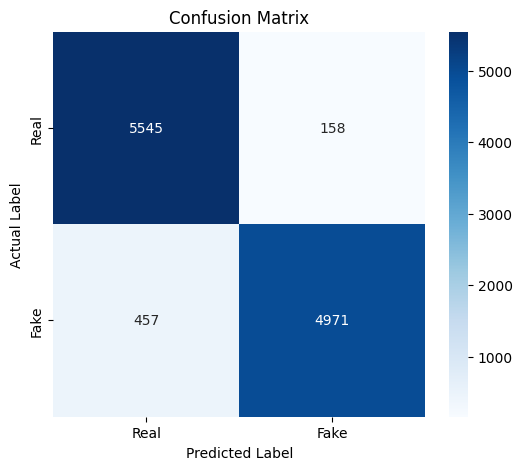

In [53]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## 24. Comparison of Machine Learning Models

The performance of all evaluated classifiers is compared using accuracy, precision, recall, and F1-score.

F1-score is particularly important because it balances precision and recall and is therefore more informative than accuracy when evaluating fake-news detection.

In [54]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.971162,0.980976,0.959469,0.970103
1,Logistic Regression,0.965232,0.976375,0.951732,0.963896
0,Naive Bayes,0.961639,0.975471,0.945099,0.960045
4,Random Forest,0.959213,0.972096,0.943441,0.957554
5,KNN,0.944749,0.969195,0.915807,0.941745
3,Decision Tree,0.914293,0.914106,0.909727,0.911911


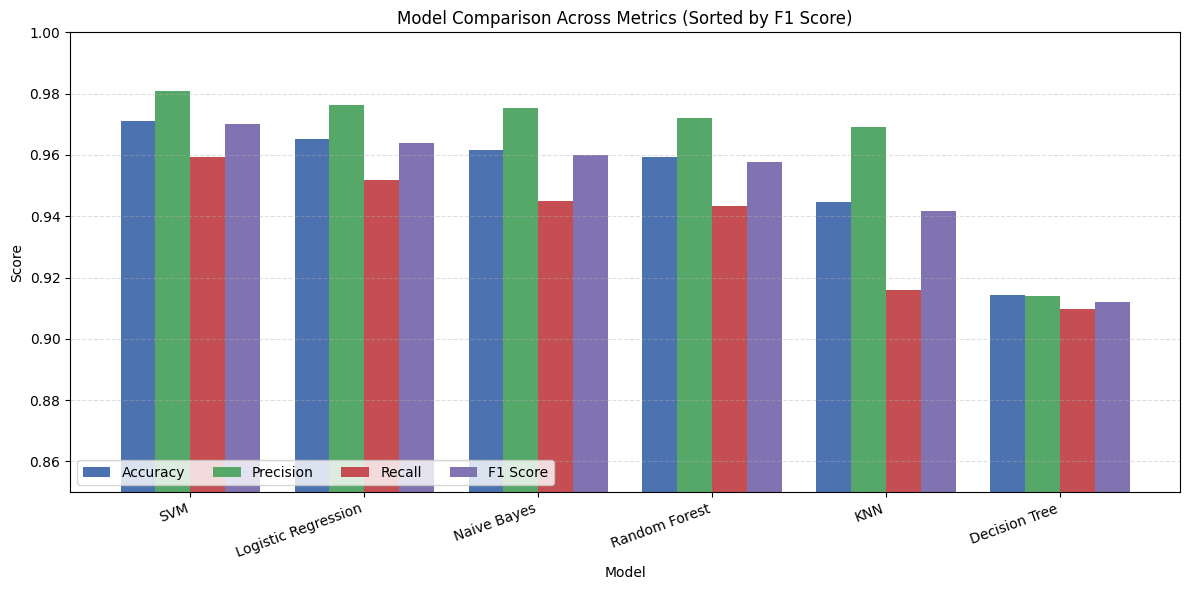

In [46]:

results_sorted = results_df.sort_values(by="F1 Score", ascending=False)

# ---- Chart 1: Grouped bar chart across all 4 metrics ----
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(results_sorted))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_sorted[metric], width, label=metric, color=colors[i])

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Comparison Across Metrics (Sorted by F1 Score)")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_sorted["Model"], rotation=20, ha="right")
ax.set_ylim(0.85, 1.0)
ax.legend(loc="lower left", ncol=4)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("model_comparison_grouped.png", dpi=150)
plt.show()

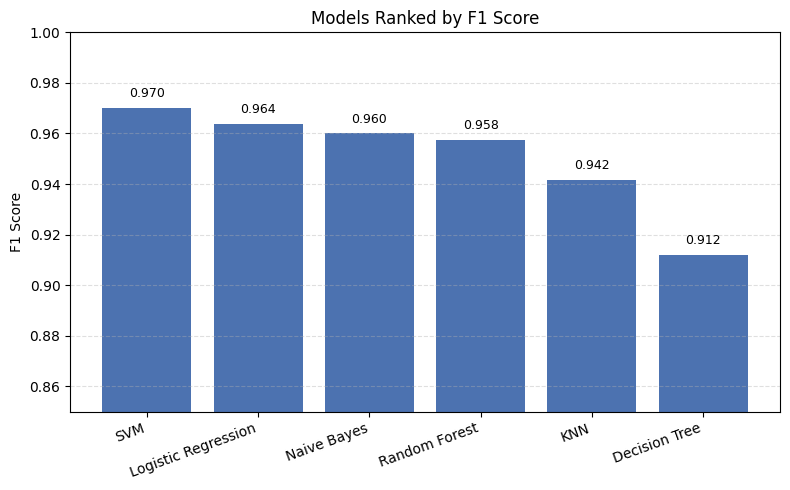

In [47]:
results_sorted = results_df.sort_values(by="F1 Score", ascending=False)

# ---- Chart 2: F1 Score ranked, single metric ----
fig2, ax2 = plt.subplots(figsize=(8, 5))
bars = ax2.bar(results_sorted["Model"], results_sorted["F1 Score"], color="#4C72B0")
ax2.set_ylabel("F1 Score")
ax2.set_title("Models Ranked by F1 Score")
ax2.set_ylim(0.85, 1.0)
plt.xticks(rotation=20, ha="right")
for bar, score in zip(bars, results_sorted["F1 Score"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
              f"{score:.3f}", ha="center", va="bottom", fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("model_f1_ranked.png", dpi=150)
plt.show()

## 25. Best Performing Model
The best-performing classifier is evaluated using four primary metrics:

- **Accuracy:** proportion of correctly classified news articles.
- **Precision:** proportion of articles predicted as fake that are actually fake.
- **Recall:** proportion of actual fake articles correctly identified.
- **F1-score:** harmonic mean of precision and recall.

Based on the experimental results, **Support Vector Machine (SVM)** was selected as the best-performing classifier.

The model achieved:

- **Accuracy:** 97.12%
- **Precision:** 98.10%
- **Recall:** 95.95%
- **F1-score:** 97.01%

The strong precision indicates that most news articles predicted as fake were actually fake. The recall of 95.95% indicates that the model successfully identified most of the fake-news articles in the test set.

The F1-score of 97.01% demonstrates a strong balance between precision and recall.

Therefore, SVM was selected as the final baseline classifier for the Nepali fake-news detection task.

In [55]:
# ---- Choose the best model based on F1 Score ----
best_model_row = results_df.sort_values(
    by=["F1 Score", "Accuracy"], ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name}")
print(best_model_row)

Best model: SVM
Model             SVM
Accuracy     0.971162
Precision    0.980976
Recall       0.959469
F1 Score     0.970103
Name: 2, dtype: object


## 26. SVM Classification Report

The detailed classification report for the selected SVM model is presented below. It provides class-wise precision, recall, F1-score, and support for both real and fake news.

In [57]:
y_pred_best = best_model.predict(X_test_tfidf)

print(f"Classification Report — Best Model: {best_model_name}\n")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["Real", "Fake"]
    )
)

Classification Report — Best Model: SVM

              precision    recall  f1-score   support

        Real       0.96      0.98      0.97      5703
        Fake       0.98      0.96      0.97      5428

    accuracy                           0.97     11131
   macro avg       0.97      0.97      0.97     11131
weighted avg       0.97      0.97      0.97     11131



## 27. SVM Confusion Matrix

The confusion matrix is used to analyze the classification errors made by the final SVM model.

It shows the number of:

- True Negatives
- False Positives
- False Negatives
- True Positives

This is particularly important for fake-news detection because false negatives represent fake news that the model incorrectly identifies as real.

SVM Confusion Matrix:
[[5602  101]
 [ 220 5208]]


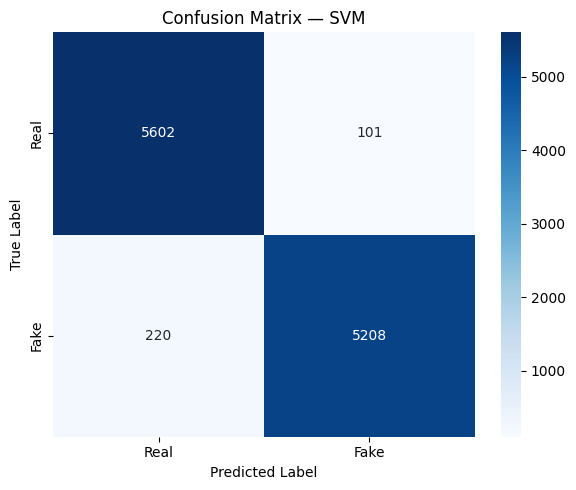

In [60]:

cm_svm = confusion_matrix(y_test, y_pred_best)
print("SVM Confusion Matrix:")
print(cm_svm)

# Visualize as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=150)
plt.show()

## 10. ROC-AUC Evaluation

Receiver Operating Characteristic (ROC) curves were used to evaluate the ability of the classification models to distinguish between real news (label 0) and fake news (label 1) across different classification thresholds. The Area Under the ROC Curve (AUC) provides a threshold-independent measure of model discrimination, where a value closer to 1.0 indicates better classification performance.

ROC-AUC was calculated on the test set for each classifier using its probability estimates or decision scores. The ROC curves were plotted together to compare the discriminative performance of the evaluated models.

A higher ROC-AUC value indicates that the model is better able to distinguish between real and fake news across different decision thresholds.

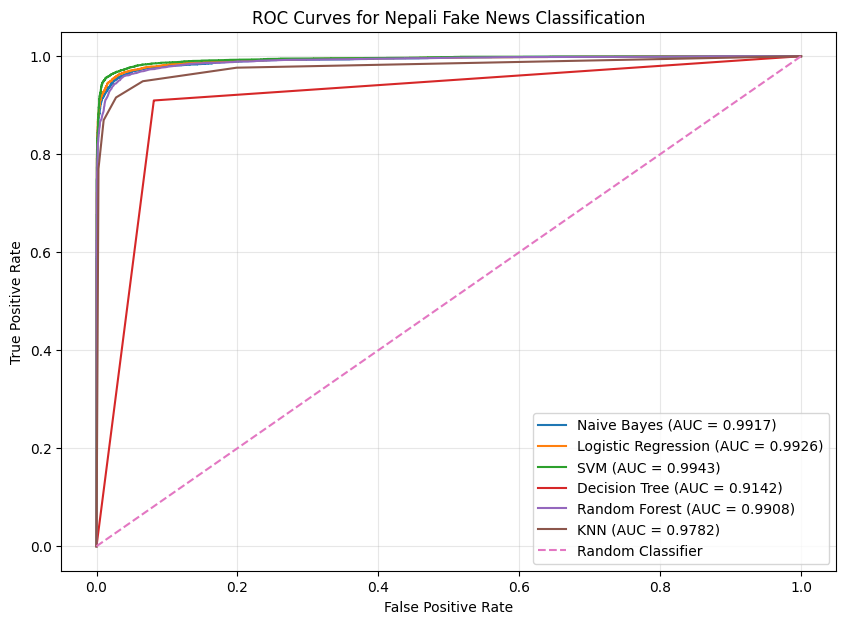

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Nepali Fake News Classification")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Error Analysis

The incorrectly classified news articles are examined to identify common patterns and potential weaknesses of the classification model. False positives and false negatives are analyzed separately to understand the types of news that are difficult for the model to classify correctly.

This analysis provides qualitative insight into the model's limitations and helps identify areas where further preprocessing, feature engineering, or additional training data may improve classification performance.

In [62]:
# Train the best-performing model
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = svm_model.predict(X_test_tfidf)

# Create error analysis dataframe
error_df = pd.DataFrame({
    "news_context": X_test.reset_index(drop=True),
    "actual_label": y_test.reset_index(drop=True),
    "predicted_label": y_pred
})

# Incorrect predictions
errors = error_df[
    error_df["actual_label"] != error_df["predicted_label"]
]

print("Total test samples:", len(error_df))
print("Incorrect predictions:", len(errors))
print("Error rate:", round(len(errors) / len(error_df) * 100, 2), "%")

Total test samples: 11131
Incorrect predictions: 321
Error rate: 2.88 %


[0 1]
False Positives (Real misclassified as Fake): 101
False Negatives (Fake misclassified as Real): 220


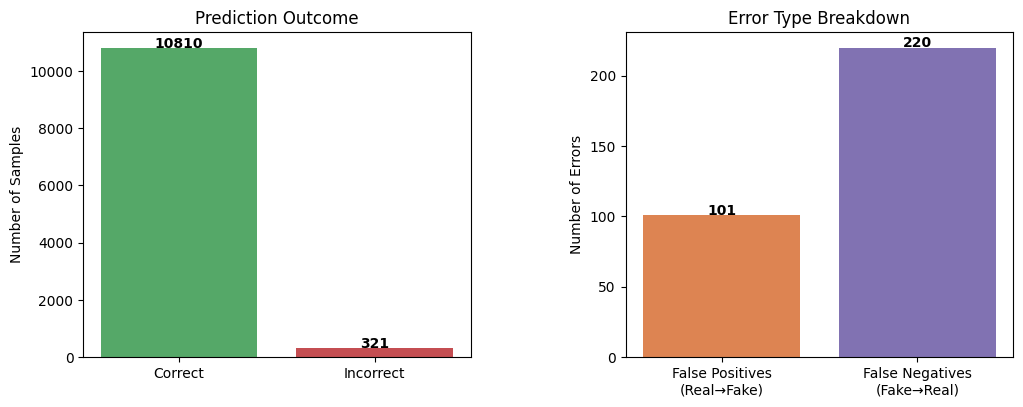


Sample misclassified examples:
                                          news_context  actual_label  \
10   काठमाण्डौ – विशेषज्ञहरूले भाकि गरेका छन् कि २०...             1   
20   शीर्षक: टेलिपोर्टेशन उपकरणको पहिलो सार्वजनिक प...             1   
112  कांग्रेसको नयाँ नीति: २०२६ मा सबै नागरिकलाई स्...             0   
124  भू-चालको कारण २०२४ को पहिलो त्रैमासिकमा काठमाड...             0   
193        शीर्षक: काठमाडौमा चोरीको घटनामा १००% वृद्धि             0   
196  शिक्षा – नेपाल शिक्षा मन्त्रालयले २०२५ मा सबै ...             0   
204  शीर्षक: नयाँ COVID‑19 वैक्सिनको प्रयोग पछि ५०%...             1   
358  शीर्षक: ‘पर्यटन कर’ २०% बढाउने निर्णय\n\nकाठमा...             1   
378  शीर्षक: नेपालमा पहिलो बार स्वच्छ पानीको आपूर्त...             1   
402  नेपालमा भोलिदेखि भूकम्पको सम्भावना रहनेछ, मौसम...             1   

     predicted_label  
10                 0  
20                 0  
112                1  
124                1  
193                1  
196                1  
204           

In [65]:
import matplotlib.pyplot as plt

# Check which integer corresponds to which class first
print(y_test.unique())  # confirm labels are 0 and 1

# Adjust these based on your actual encoding, e.g. 1 = Fake, 0 = Real
FAKE_LABEL = 1
REAL_LABEL = 0

false_positives = errors[
    (errors["actual_label"] == REAL_LABEL) & (errors["predicted_label"] == FAKE_LABEL)
]
false_negatives = errors[
    (errors["actual_label"] == FAKE_LABEL) & (errors["predicted_label"] == REAL_LABEL)
]

print(f"False Positives (Real misclassified as Fake): {len(false_positives)}")
print(f"False Negatives (Fake misclassified as Real): {len(false_negatives)}")

# Bar chart: correct vs incorrect, and error type breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = [len(error_df) - len(errors), len(errors)]
axes[0].bar(["Correct", "Incorrect"], counts, color=["#55A868", "#C44E52"])
axes[0].set_title("Prediction Outcome")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

error_counts = [len(false_positives), len(false_negatives)]
axes[1].bar(["False Positives\n(Real→Fake)", "False Negatives\n(Fake→Real)"],
            error_counts, color=["#DD8452", "#8172B2"])
axes[1].set_title("Error Type Breakdown")
axes[1].set_ylabel("Number of Errors")
for i, v in enumerate(error_counts):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.subplots_adjust(top=0.85, bottom=0.2, wspace=0.4)
plt.savefig("error_analysis.png", dpi=150)
plt.show()

print("\nSample misclassified examples:")
print(errors.head(10))

# Saving the model for later use

In [69]:
import joblib

# Save the best model and the vectorizer used to transform text
joblib.dump(best_model, "best_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved!")

Model and vectorizer saved!


In [70]:
import joblib

best_model = joblib.load("best_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model and vectorizer loaded, ready to use!")

Model and vectorizer loaded, ready to use!


In [72]:
label_map = {0: "Real", 1: "Fake"}

new_text = ["काठमाण्डौमा आजको मौसम राम्रो छ।"]
new_text_tfidf = tfidf.transform(new_text)
prediction = best_model.predict(new_text_tfidf)

print(f"Prediction: {label_map[prediction[0]]}")

Prediction: Real
